# Nettoyage — Metadata ResStock national
Ce notebook supprime les colonnes inutiles et produit un fichier `metadata_clean.parquet` réutilisable.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# Racine du projet — 2 niveaux au-dessus de ce notebook
# notebooks/02_nettoyage/ -> notebooks/ -> FlexiMax/
ROOT = Path().resolve().parent.parent

DATA_RAW       = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
FIGURES        = ROOT / 'reports' / 'figures'

print('Racine projet :', ROOT)

Racine projet : \\FS-SOP\Staff-CMA\yzouarhi\Bureau\Data\FlexiMax


## 1. Chargement des données

In [2]:
# Chargement du fichier national complet
df = pd.read_parquet(DATA_RAW / 'upgrade0.parquet')

print('Shape initiale :', df.shape)
print(f'  {df.shape[0]:,} batiments')
print(f'  {df.shape[1]:,} colonnes')

Shape initiale : (549971, 771)
  549,971 batiments
  771 colonnes


## 2. Définition des colonnes à supprimer

In [3]:
# --- GROUPE 1 : upgrade.* ---
# Toutes les colonnes upgrade.* sont a 100% vides dans upgrade=0 (baseline)
drop_upgrade = [c for c in df.columns if c.startswith('upgrade.')]
print(f'upgrade.*       : {len(drop_upgrade)} colonnes supprimees')

# --- GROUPE 2 : calc.weighted.* ---
# Agregats nationaux en TBtu — pas utiles par batiment individuel
drop_calc = [c for c in df.columns if c.startswith('calc.')]
print(f'calc.weighted.* : {len(drop_calc)} colonnes supprimees')

# --- GROUPE 3 : colonnes savings/reduction dans out.* ---
# Ces colonnes representent des economies par rapport a un upgrade
# Dans upgrade=0 (baseline), elles sont toutes a 0 ou NaN
drop_savings = [
    c for c in df.columns
    if c.startswith('out.') and ('savings' in c or 'reduction' in c)
]
print(f'out.* savings/reduction : {len(drop_savings)} colonnes supprimees')

# --- GROUPE 4 : in.simulation_control.* ---
# Parametres techniques de la simulation EnergyPlus
# Ex: begin_month=1, end_month=12, timestep=15 — identiques pour tous les batiments
drop_sim = [c for c in df.columns if 'simulation_control' in c]
print(f'in.simulation_control.* : {len(drop_sim)} colonnes supprimees')

# --- GROUPE 5 : in.utility_bill.* ---
# Tarifs regionaux de l'energie ($/kWh, $/therm...)
# Pas une caracteristique du batiment — deja reflete dans out.utility_bills.*
drop_tarif = [c for c in df.columns if c.startswith('in.utility_bill')]
print(f'in.utility_bill.*       : {len(drop_tarif)} colonnes supprimees')

# --- GROUPE 6 : doublons binned ---
# Versions regroupees de colonnes deja presentes en version plus precise
drop_bins = [
    'in.geometry_floor_area_bin',
    'in.geometry_story_bin',
    'in.geometry_stories_low_rise',
    'in.geometry_space_combination',
    'in.geometry_building_type_height',
    'in.vintage_acs',
    'in.income_recs_2015',
    'in.income_recs_2020',
    'in.custom_state',
    'in.electric_panel_service_rating_bin..a'
]
drop_bins = [c for c in drop_bins if c in df.columns]
print(f'doublons binned         : {len(drop_bins)} colonnes supprimees')

upgrade.*       : 20 colonnes supprimees
calc.weighted.* : 172 colonnes supprimees
out.* savings/reduction : 164 colonnes supprimees
in.simulation_control.* : 6 colonnes supprimees
in.utility_bill.*       : 8 colonnes supprimees
doublons binned         : 10 colonnes supprimees


## 3. Application du nettoyage

In [4]:
# On regroupe toutes les colonnes a supprimer dans un seul ensemble
toutes_suppressions = set(drop_upgrade + drop_calc + drop_savings + drop_sim + drop_tarif + drop_bins)

# drop() supprime les colonnes listees — axis=1 signifie colonnes
a_supprimer = [c for c in toutes_suppressions if c in df.columns]
df_clean = df.drop(columns=a_supprimer)

print('Shape initiale :', df.shape)
print('Shape nettoyee :', df_clean.shape)
print(f'Colonnes supprimees : {df.shape[1] - df_clean.shape[1]}')
print(f'Colonnes conservees : {df_clean.shape[1]}')

Shape initiale : (549971, 771)
Shape nettoyee : (549971, 391)
Colonnes supprimees : 380
Colonnes conservees : 391


## 4. Vérification du résultat

In [5]:
# Compter les colonnes restantes par famille
familles_clean = {}
for c in df_clean.columns:
    prefix = c.split('.')[0]
    familles_clean[prefix] = familles_clean.get(prefix, 0) + 1

print('=== Colonnes restantes par famille ===')
for k, v in sorted(familles_clean.items(), key=lambda x: -x[1]):
    print(f'  {k:20s} : {v} colonnes')

=== Colonnes restantes par famille ===
  out                  : 221 colonnes
  in                   : 165 colonnes
  bldg_id              : 1 colonnes
  completed_status     : 1 colonnes
  upgrade              : 1 colonnes
  weight               : 1 colonnes
  applicability        : 1 colonnes


In [6]:
# Verifier qu'il ne reste plus de colonnes entierement vides
pct_manquant = df_clean.isnull().mean()

entierement_vides = pct_manquant[pct_manquant == 1.0]
print(f'Colonnes 100% vides restantes : {len(entierement_vides)}')

moitie_vides = pct_manquant[pct_manquant > 0.5]
print(f'Colonnes >50% vides           : {len(moitie_vides)}')
if len(moitie_vides) > 0:
    print(moitie_vides.sort_values(ascending=False).head(10))

Colonnes 100% vides restantes : 0
Colonnes >50% vides           : 0


## 5. Diagramme — ce qui a été gardé et supprimé

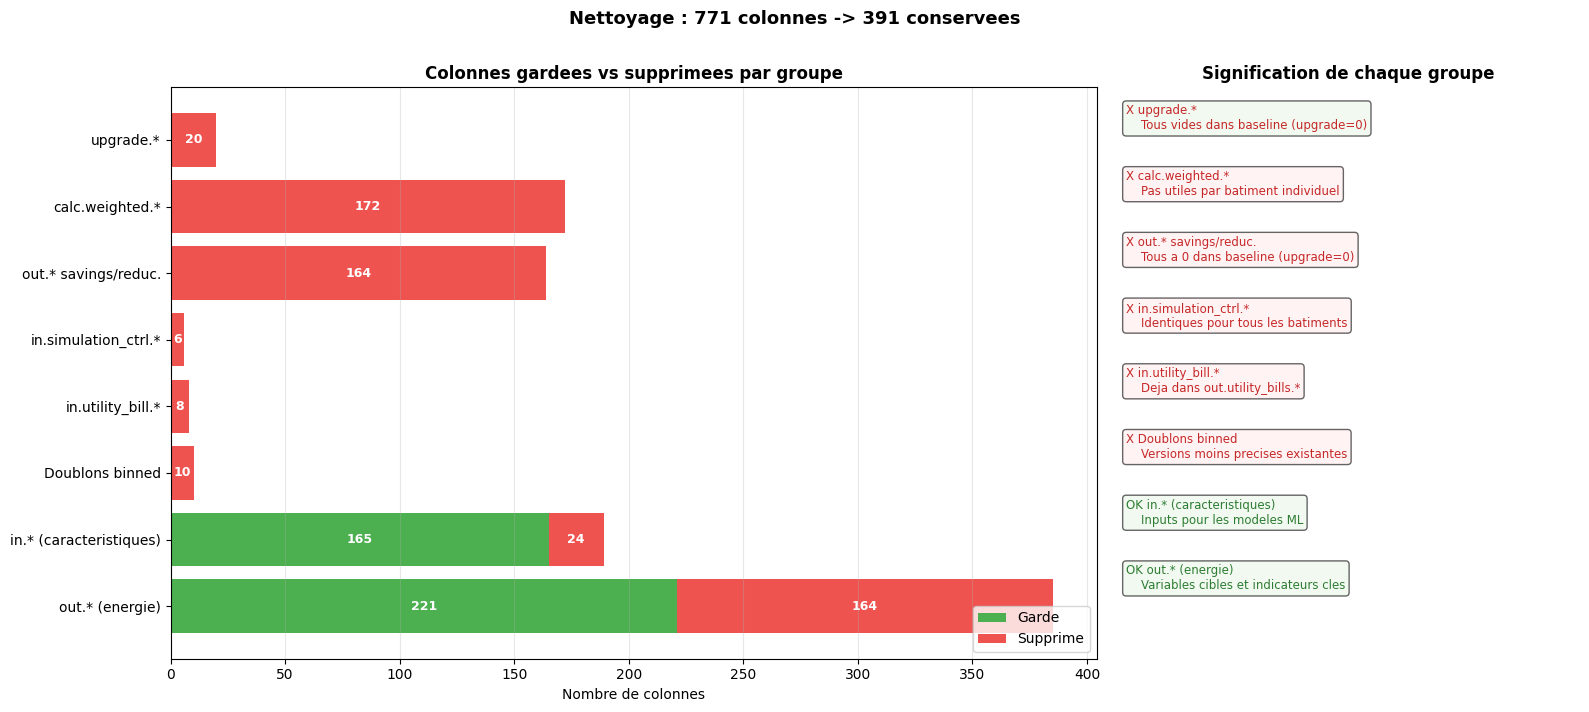

Diagramme sauvegarde : \\FS-SOP\Staff-CMA\yzouarhi\Bureau\Data\FlexiMax\reports\figures\diagramme_nettoyage.png


In [7]:
groupes = [
    {'nom': 'upgrade.*',             'total': len(drop_upgrade), 'garde': 0, 'raison': 'Tous vides dans baseline (upgrade=0)'},
    {'nom': 'calc.weighted.*',       'total': len(drop_calc),    'garde': 0, 'raison': 'Pas utiles par batiment individuel'},
    {'nom': 'out.* savings/reduc.',  'total': len(drop_savings), 'garde': 0, 'raison': 'Tous a 0 dans baseline (upgrade=0)'},
    {'nom': 'in.simulation_ctrl.*',  'total': len(drop_sim),     'garde': 0, 'raison': 'Identiques pour tous les batiments'},
    {'nom': 'in.utility_bill.*',     'total': len(drop_tarif),   'garde': 0, 'raison': 'Deja dans out.utility_bills.*'},
    {'nom': 'Doublons binned',       'total': len(drop_bins),    'garde': 0, 'raison': 'Versions moins precises existantes'},
    {'nom': 'in.* (caracteristiques)', 'total': len([c for c in df.columns if c.startswith('in.')]),
                                       'garde': len([c for c in df_clean.columns if c.startswith('in.')]),
                                       'raison': 'Inputs pour les modeles ML'},
    {'nom': 'out.* (energie)',         'total': len([c for c in df.columns if c.startswith('out.')]),
                                       'garde': len([c for c in df_clean.columns if c.startswith('out.')]),
                                       'raison': 'Variables cibles et indicateurs cles'},
]
for g in groupes:
    g['supprime'] = g['total'] - g['garde']

labels   = [g['nom'] for g in groupes]
gardes   = [g['garde'] for g in groupes]
supprime = [g['supprime'] for g in groupes]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2, 1]})

ax = axes[0]
y = range(len(labels))
ax.barh(y, gardes,   color='#4CAF50', label='Garde')
ax.barh(y, supprime, left=gardes, color='#EF5350', label='Supprime')
for i, (g, s) in enumerate(zip(gardes, supprime)):
    if g > 0:
        ax.text(g / 2, i, str(g), va='center', ha='center', color='white', fontweight='bold', fontsize=9)
    if s > 0:
        ax.text(g + s / 2, i, str(s), va='center', ha='center', color='white', fontweight='bold', fontsize=9)
ax.set_yticks(list(y))
ax.set_yticklabels(labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Nombre de colonnes')
ax.set_title('Colonnes gardees vs supprimees par groupe', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

ax2 = axes[1]
ax2.axis('off')
ax2.set_title('Signification de chaque groupe', fontsize=12, fontweight='bold')
couleurs = ['#E8F5E9', '#FFEBEE', '#FFEBEE', '#FFEBEE', '#FFEBEE', '#FFEBEE', '#E8F5E9', '#E8F5E9']
for i, g in enumerate(groupes):
    y_pos = 0.97 - i * (0.92 / len(groupes))
    couleur = '#2E7D32' if g['garde'] > 0 else '#C62828'
    symbole = 'OK' if g['garde'] > 0 else 'X'
    texte = f"{symbole} {g['nom']}\n    {g['raison']}"
    ax2.text(0.02, y_pos, texte, transform=ax2.transAxes, fontsize=8.5, color=couleur,
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor=couleurs[i], alpha=0.6))

plt.suptitle(f'Nettoyage : {df.shape[1]} colonnes -> {df_clean.shape[1]} conservees',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'diagramme_nettoyage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Diagramme sauvegarde :', FIGURES / 'diagramme_nettoyage.png')

## 6. Export du fichier nettoyé

In [8]:
# Sauvegarde dans data/processed/
df_clean.to_parquet(DATA_PROCESSED / 'metadata_clean.parquet', index=False)

print('Fichier sauvegarde :', DATA_PROCESSED / 'metadata_clean.parquet')
print('Shape finale :', df_clean.shape)
print()
print('Pour recharger dans un autre notebook :')
print("  df = pd.read_parquet(DATA_PROCESSED / 'metadata_clean.parquet')")

FileNotFoundError: [Errno 2] Error writing bytes to file. Detail: [errno 2] No such file or directory